
# Numerical Simulations for the Coupled Sediment--Chemical Transport Model

This notebook presents a structured numerical study of the one-dimensional model

a) Sediment concentration:
$$
\frac{\partial S}{\partial t} + v\frac{\partial S}{\partial x}
= D_S\frac{\partial^2 S}{\partial x^2} - \mu_1 CS,
$$

b) Chemical concentration:
$$
\frac{\partial C}{\partial t} + v\frac{\partial C}{\partial x}
= D_C\frac{\partial^2 C}{\partial x^2} - \mu_2 CS - \mu_C C.
$$

We consider the spatial domain $0\le x\le L$ with the following conditions:
- inlet conditions: $S(0,t)=S_{\mathrm{in}}$, $C(0,t)=C_{\mathrm{in}}$,
- outlet conditions: $\partial_x S(L,t)=0$, $\partial_x C(L,t)=0$,
- initial conditions: $S(x,0)=S_0(x)$ and $C(x,0)=C_0(x)$.

The goal is to illustrate the following points:
1. the initial profiles of $S(x,0)$ and $C(x,0)$,
2. spatial profiles at selected times,
3. the sediment dissolution term $\mu_1 C(x,t)S(x,t)$,
4. the chemical consumption term $\mu_2 C(x,t)S(x,t)$,
5. the effect of the advection velocity $v$,
6. the effect of the sediment diffusion coefficient $D_S$,
7. the effect of the chemical diffusion coefficient $D_C$,
8. the effect of the coefficient $\mu_1$,
9. the effect of the coefficient $\mu_2$.

The discussion is written in basic academic English and follows the model described in the PDF document.



## 1. Choice of parameter values

The PDF document gives the mathematical structure of the model, but it does not provide a calibrated experimental data set.
Therefore, the parameter values used below are **illustrative but physically plausible**. They are chosen to make advection,
diffusion, and reaction visible on the same time window.

### Main idea behind the choices
- The velocity $v$ is chosen in a range that is consistent with a slow or moderate river current.
- The coefficients $D_S$ and $D_C$ are treated as effective diffusion or dispersion coefficients, in the usual spirit of one-dimensional river transport models.
- The coefficients $\mu_1$, $\mu_2$, and $\mu_C$ are selected so that the interaction between sediment and chemical is visible, while the solution remains stable and positive in the numerical simulations.

### References used to justify the general scale of the parameters
- J. D. Logan, *Transport Modeling in Hydrogeochemical Systems*, Springer, 2001.
- S. C. Chapra, *Surface Water-Quality Modeling*, Waveland Press, 2008.

These references motivate the use of advection--diffusion--reaction equations for river systems and support the use of moderate velocities and effective diffusion coefficients in such simplified one-dimensional studies.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# -----------------------------
# Baseline numerical parameters
# -----------------------------
params = {
    'L': 1000.0 ,   # m
    'T': 400.0,    # s
    'Nx': 201,
    'dt': 2.0,        # s
    'v': 0.16,     # m/s
    'D_S': 1.2,    # m^2/s
    'D_C': 1.8 ,     # m^2/s
    'mu1': 0.015,    # m^3 kg^-1 s^-1
    'mu2': 0.01 ,   # m^3 kg^-1 s^-1
    'mu_C': 2e-4,   # s^-1
    'S_in': 0.20,     # kg/m^3
    'C_in': 0.15 ,     # kg/m^3
}

x = np.linspace(0, params['L'], params['Nx'])
dx = x[1] - x[0]

def S0(x):
    return 1.20 * np.exp(-((x - 180.0)/90.0)**2)

def C0(x):
    return 0.90 * np.exp(-((x - 260.0)/110.0)**2)

print(f"dx = {dx:.2f} m")
print(f"Number of time steps = {int(params['T']/params['dt'])}")


dx = 5.00 m
Number of time steps = 200



## 2. Numerical method

We use a finite-difference scheme:
- an **upwind approximation** for the advection terms because the flow is from left to right ($v>0$),
- a **centered approximation** for the diffusion terms,
- an **explicit time stepping** for the full system.

This method is simple and appropriate for an illustrative notebook. The time step is chosen small enough to satisfy standard stability restrictions for advection and diffusion.


In [2]:

def simulate(par, save_every=20):
    """Solve the coupled PDE system and save snapshots every `save_every` time steps."""
    L = par['L']
    T = par['T']
    Nx = par['Nx']
    dt = par['dt']
    v = par['v']
    D_S = par['D_S']
    D_C = par['D_C']
    mu1 = par['mu1']
    mu2 = par['mu2']
    mu_C = par['mu_C']
    S_in = par['S_in']
    C_in = par['C_in']

    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    Nt = int(T / dt)

    S = S0(x).copy()
    C = C0(x).copy()

    # enforce inlet at t=0
    S[0] = S_in
    C[0] = C_in
    # enforce outlet zero-gradient at t=0
    S[-1] = S[-2]
    C[-1] = C[-2]

    times = [0.0]
    S_hist = [S.copy()]
    C_hist = [C.copy()]

    for n in range(1, Nt + 1):
        S_old = S.copy()
        C_old = C.copy()

        # interior points: upwind for advection, centered for diffusion
        adv_S = -v * (S_old[1:-1] - S_old[:-2]) / dx
        adv_C = -v * (C_old[1:-1] - C_old[:-2]) / dx

        diff_S = D_S * (S_old[2:] - 2*S_old[1:-1] + S_old[:-2]) / dx**2
        diff_C = D_C * (C_old[2:] - 2*C_old[1:-1] + C_old[:-2]) / dx**2

        react_S = -mu1 * S_old[1:-1] * C_old[1:-1]
        react_C = -mu2 * S_old[1:-1] * C_old[1:-1] - mu_C * C_old[1:-1]

        S[1:-1] = S_old[1:-1] + dt * (adv_S + diff_S + react_S)
        C[1:-1] = C_old[1:-1] + dt * (adv_C + diff_C + react_C)

        # positivity correction for concentrations
        S[1:-1] = np.maximum(S[1:-1], 0.0)
        C[1:-1] = np.maximum(C[1:-1], 0.0)

        # boundary conditions
        S[0] = S_in
        C[0] = C_in
        S[-1] = S[-2]   # zero diffusive flux at x = L
        C[-1] = C[-2]

        if n % save_every == 0 or n == Nt:
            times.append(n * dt)
            S_hist.append(S.copy())
            C_hist.append(C.copy())

    return x, np.array(times), np.array(S_hist), np.array(C_hist)


def nearest_index(values, target):
    return int(np.argmin(np.abs(values - target)))


def total_mass(U, x):
    return np.trapz(U, x)


In [3]:

# Run the baseline simulation
x, times, S_hist, C_hist = simulate(params, save_every=20)

# Selected times for profile plots
selected_times = [0, 100, 200, 300, 400] #[0.0, 1000.0, 2000.0, 4000.0]
selected_ids = [nearest_index(times, t) for t in selected_times]
selected_times_used = [times[i] for i in selected_ids]

print("Saved time snapshots:", len(times))
print("Selected times used:", selected_times_used)


Saved time snapshots: 11
Selected times used: [0.0, 80.0, 200.0, 280.0, 400.0]



## 3. Initial profiles of $S(x,0)$ and $C(x,0)$

We illustrate the initial profiles because they are the starting point of the dynamics.
Without showing the initial conditions, it is difficult to know whether the observed evolution really comes from the model,
or simply from a particular choice of initial data.


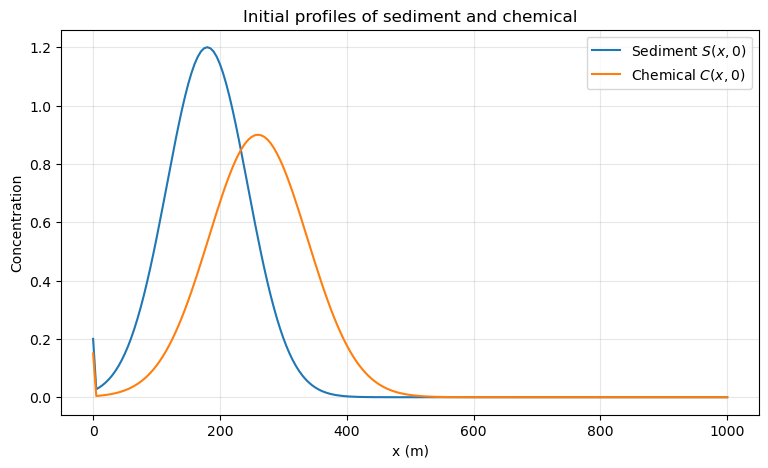

In [4]:

plt.figure(figsize=(9,5))
plt.plot(x, S_hist[0], label='Sediment $S(x,0)$')
plt.plot(x, C_hist[0], label='Chemical $C(x,0)$')
plt.xlabel('x (m)')
plt.ylabel('Concentration')
plt.title('Initial profiles of sediment and chemical')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- The sediment and chemical are initially concentrated in localized regions.
- The two peaks are close, but they are not exactly centered at the same position.
- This is useful because the interaction term $CS$ will be strong only where the two profiles overlap.



## 4. Spatial profiles at selected times

We illustrate spatial profiles at selected times because time slices help us observe:
- whether the peak moves downstream,
- whether the profile becomes flatter,
- whether the concentration decreases quickly or slowly,
- whether the interaction remains localized or becomes more spread out.


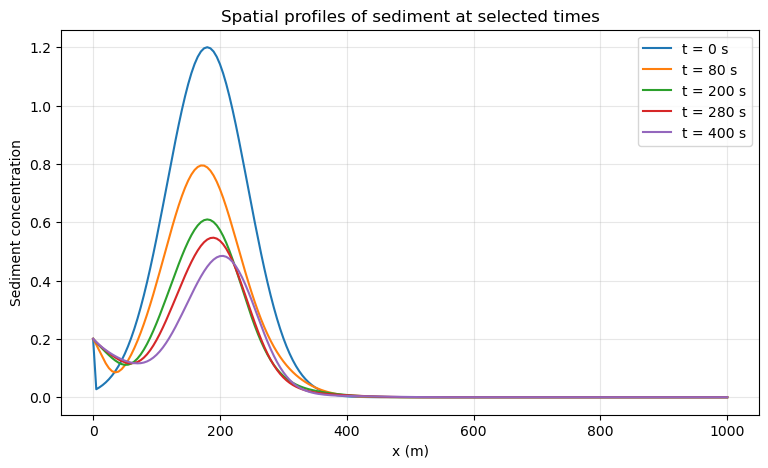

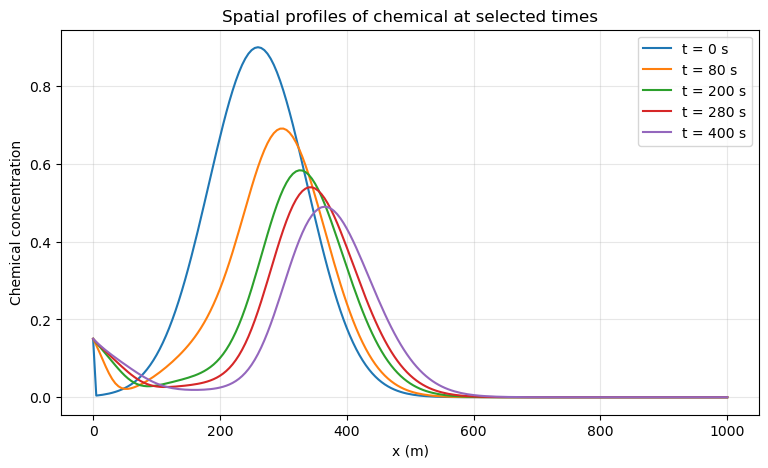

In [5]:

plt.figure(figsize=(9,5))
for idx, t in zip(selected_ids, selected_times_used):
    plt.plot(x, S_hist[idx], label=f't = {t:.0f} s')
plt.xlabel('x (m)')
plt.ylabel('Sediment concentration')
plt.title('Spatial profiles of sediment at selected times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))
for idx, t in zip(selected_ids, selected_times_used):
    plt.plot(x, C_hist[idx], label=f't = {t:.0f} s')
plt.xlabel('x (m)')
plt.ylabel('Chemical concentration')
plt.title('Spatial profiles of chemical at selected times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- In both cases, the profiles move to the right because of advection.
- The peaks become lower and wider because of diffusion.
- The amplitudes also decrease because of the reaction terms, and for the chemical there is an additional natural decay.



## 5. Sediment dissolution term $\mu_1 C(x,t)S(x,t)$

This term represents the direct loss of sediment caused by the chemical. It is one of the central mechanisms of the model.
By illustrating this term, we can identify:
- where the dissolution is strongest,
- at which times it is maximal,
- whether it stays close to the inlet or is transported downstream.


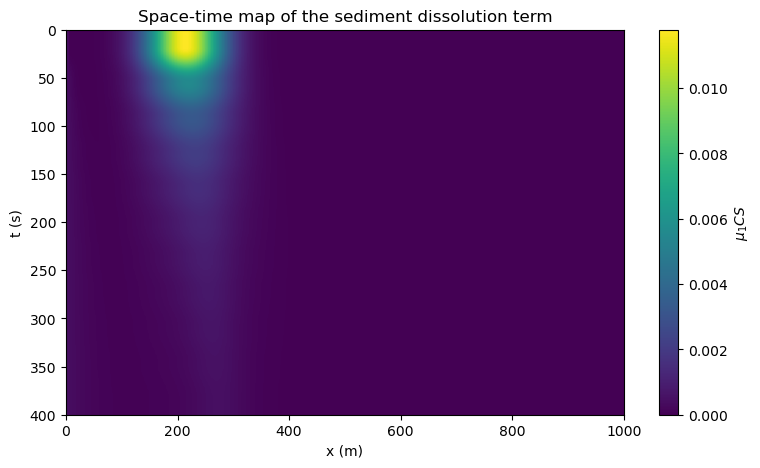

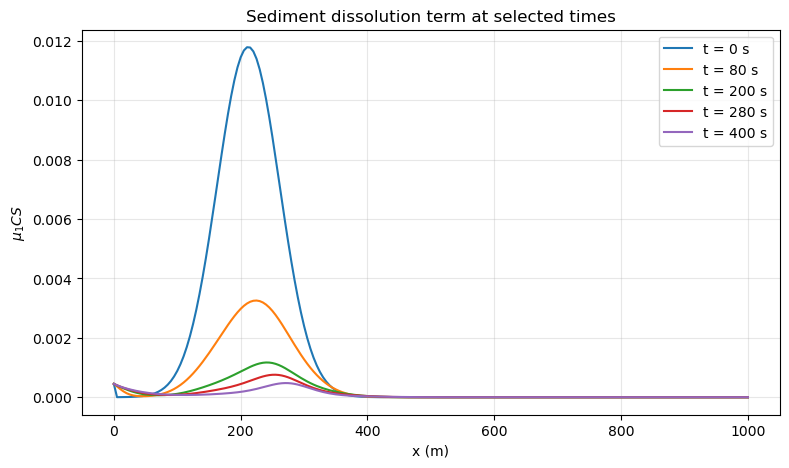

In [6]:

R1 = params['mu1'] * S_hist * C_hist

plt.figure(figsize=(9,5))
extent = [x[0], x[-1], times[-1], times[0]]
plt.imshow(R1, aspect='auto', extent=extent)
plt.colorbar(label=r'$\mu_1 CS$')
plt.xlabel('x (m)')
plt.ylabel('t (s)')
plt.title('Space-time map of the sediment dissolution term')
plt.show()

plt.figure(figsize=(9,5))
for idx, t in zip(selected_ids, selected_times_used):
    plt.plot(x, R1[idx], label=f't = {t:.0f} s')
plt.xlabel('x (m)')
plt.ylabel(r'$\mu_1 CS$')
plt.title('Sediment dissolution term at selected times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- The dissolution is strong only in regions where both $S$ and $C$ are simultaneously present.
- The maximum is localized around the overlap region of the two concentrations.
- As time increases, the active dissolution zone moves downstream and usually weakens because both concentrations decrease.



## 6. Chemical consumption term $\mu_2 C(x,t)S(x,t)$

This term represents the loss of chemical due to contact with sediment.
Although it has the same product $CS$, its physical role is different because it acts in the chemical equation.
This figure helps us see where and when the chemical is mostly consumed by interaction with sediment.


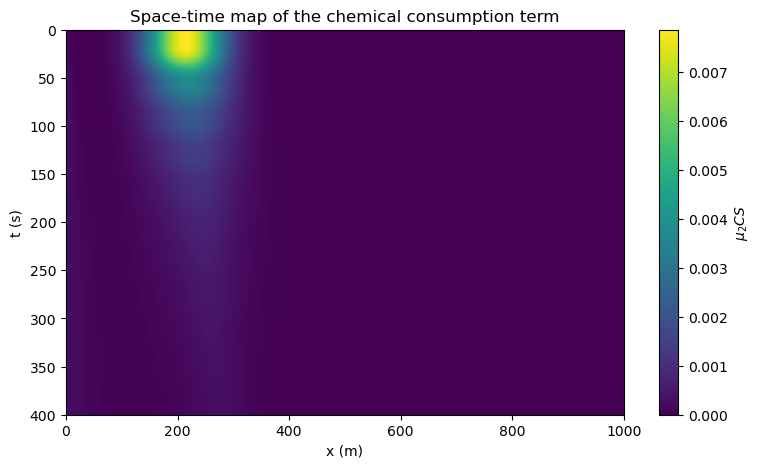

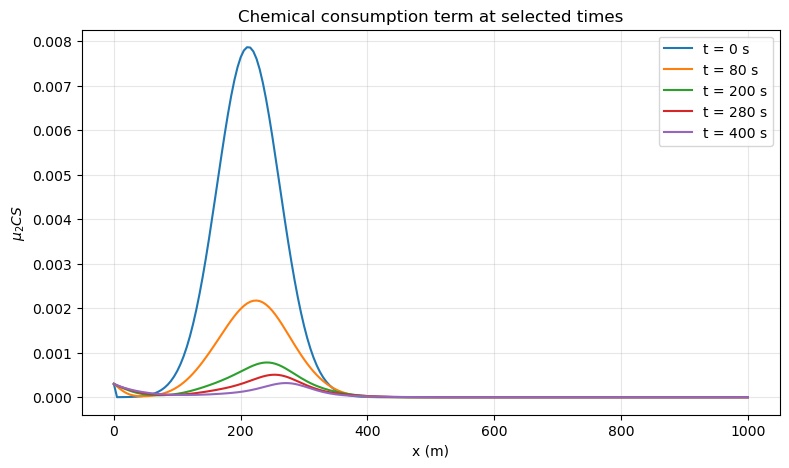

In [7]:

R2 = params['mu2'] * S_hist * C_hist

plt.figure(figsize=(9,5))
extent = [x[0], x[-1], times[-1], times[0]]
plt.imshow(R2, aspect='auto', extent=extent)
plt.colorbar(label=r'$\mu_2 CS$')
plt.xlabel('x (m)')
plt.ylabel('t (s)')
plt.title('Space-time map of the chemical consumption term')
plt.show()

plt.figure(figsize=(9,5))
for idx, t in zip(selected_ids, selected_times_used):
    plt.plot(x, R2[idx], label=f't = {t:.0f} s')
plt.xlabel('x (m)')
plt.ylabel(r'$\mu_2 CS$')
plt.title('Chemical consumption term at selected times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- The chemical is mainly consumed in the same spatial overlap region where the sediment dissolution occurs.
- The difference with the previous term comes from the coefficient $\mu_2$, which may be smaller or larger than $\mu_1$.
- This confirms that the same contact process can have two distinct physical effects.



## 7. Effect of the advection velocity $v$

We compare three values of $v$: small, medium, and large.
This is important because advection controls the transport speed toward the downstream direction.
By changing $v$, we can see whether:
- the peaks move faster,
- the contact time between $S$ and $C$ changes,
- the substances leave the domain more rapidly.


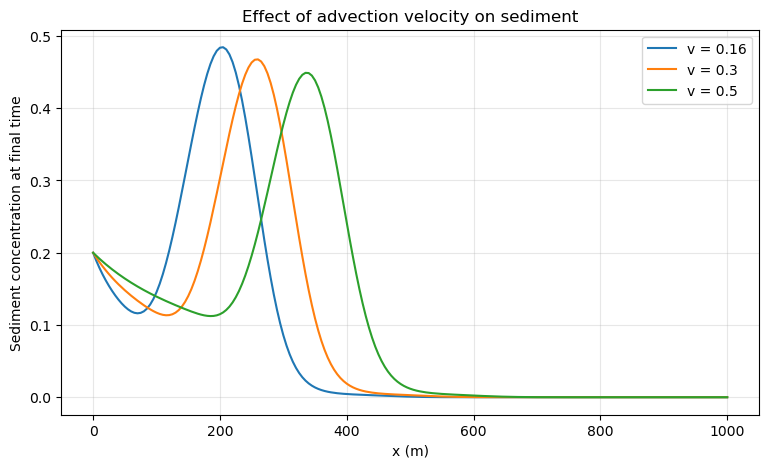

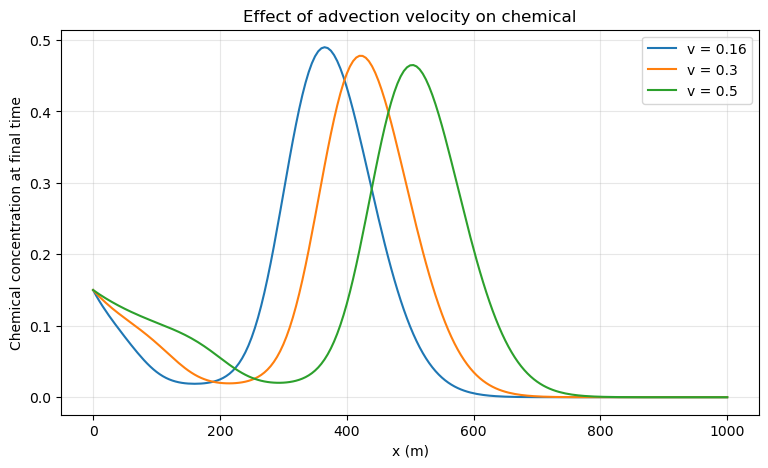

In [8]:

v_values = [0.16, 0.3, 0.5]
results_v = {}
for val in v_values:
    par = params.copy()
    par['v'] = val
    xv, tv, Sv, Cv = simulate(par, save_every=20)
    results_v[val] = (xv, tv, Sv, Cv)

plt.figure(figsize=(9,5))
for val in v_values:
    xv, tv, Sv, Cv = results_v[val]
    plt.plot(xv, Sv[-1], label=f'v = {val}')
plt.xlabel('x (m)')
plt.ylabel('Sediment concentration at final time')
plt.title('Effect of advection velocity on sediment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))
for val in v_values:
    xv, tv, Sv, Cv = results_v[val]
    plt.plot(xv, Cv[-1], label=f'v = {val}')
plt.xlabel('x (m)')
plt.ylabel('Chemical concentration at final time')
plt.title('Effect of advection velocity on chemical')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- When $v$ is larger, the profiles are transported farther downstream.
- A large velocity may reduce the time during which the two substances stay in strong contact in a given region.
- A smaller velocity keeps the interaction in the domain for a longer time.



## 8. Effect of the sediment diffusion coefficient $D_S$

We compare a low and a high value of $D_S$.
This is important because the sediment diffusion coefficient controls how much the sediment spreads in space.
A larger $D_S$ smooths the gradients, spreads the sediment over a wider region, and can modify the overlap with the chemical.


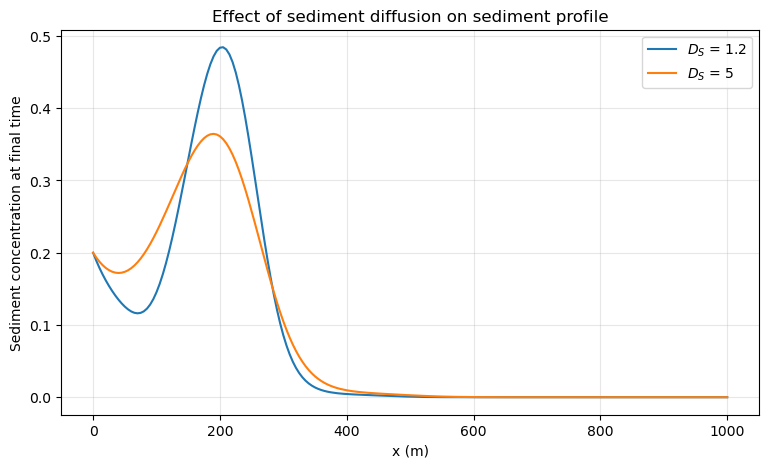

In [9]:

Ds_values = [1.2, 5]
results_Ds = {}
for val in Ds_values:
    par = params.copy()
    par['D_S'] = val
    xd, td, Sd, Cd = simulate(par, save_every=20)
    results_Ds[val] = (xd, td, Sd, Cd)

plt.figure(figsize=(9,5))
for val in Ds_values:
    xd, td, Sd, Cd = results_Ds[val]
    plt.plot(xd, Sd[-1], label=f'$D_S$ = {val}')
plt.xlabel('x (m)')
plt.ylabel('Sediment concentration at final time')
plt.title('Effect of sediment diffusion on sediment profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- For a larger $D_S$, the sediment profile is wider and smoother.
- The maximum concentration is lower because the material is more spread out.
- This can change the region where the chemical and the sediment interact.



## 9. Effect of the chemical diffusion coefficient $D_C$

We compare a low and a high value of $D_C$.
This is important because the chemical is often the more mobile component in diffusion.
By increasing $D_C$, we can see whether the chemical reaches more regions, whether the interaction zone becomes wider,
and whether the chemical peak becomes flatter more quickly.


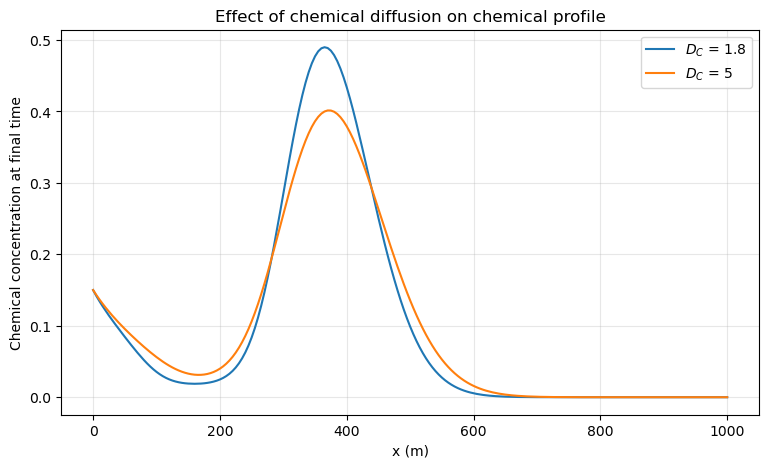

In [10]:

Dc_values = [1.80, 5]
results_Dc = {}
for val in Dc_values:
    par = params.copy()
    par['D_C'] = val
    xd, td, Sd, Cd = simulate(par, save_every=20)
    results_Dc[val] = (xd, td, Sd, Cd)

plt.figure(figsize=(9,5))
for val in Dc_values:
    xd, td, Sd, Cd = results_Dc[val]
    plt.plot(xd, Cd[-1], label=f'$D_C$ = {val}')
plt.xlabel('x (m)')
plt.ylabel('Chemical concentration at final time')
plt.title('Effect of chemical diffusion on chemical profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- A larger $D_C$ makes the chemical profile broader and flatter.
- The chemical can then interact with sediment over a wider spatial region.
- At the same time, the peak value decreases because the same quantity is distributed over a larger interval.



## 10. Effect of the coefficient $\mu_1$

We compare several values of $\mu_1$ because this coefficient controls the intensity of sediment dissolution.
It is one of the most important parameters for the question: **how much sediment survives?**
We illustrate its effect using both the final sediment profile and the total sediment mass over time.


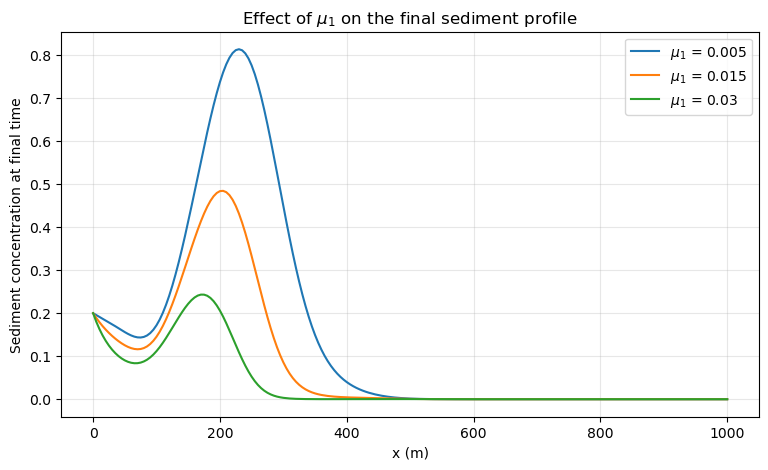

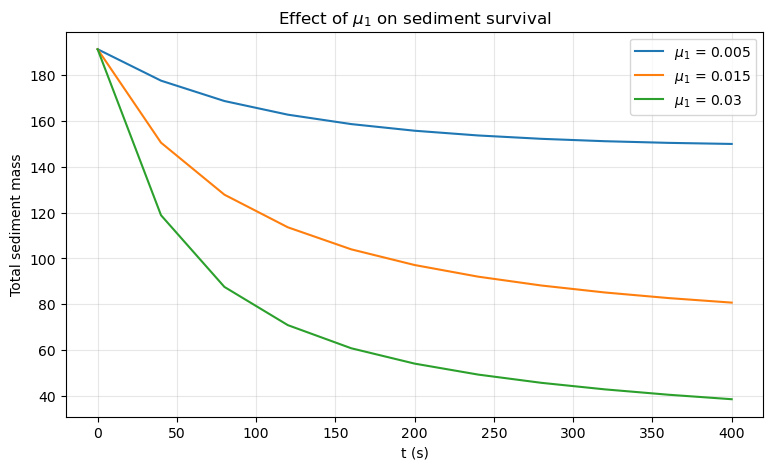

In [11]:

mu1_values = [0.005, 0.015, 0.030]
results_mu1 = {}
for val in mu1_values:
    par = params.copy()
    par['mu1'] = val
    xm, tm, Sm, Cm = simulate(par, save_every=20)
    results_mu1[val] = (xm, tm, Sm, Cm)

plt.figure(figsize=(9,5))
for val in mu1_values:
    xm, tm, Sm, Cm = results_mu1[val]
    plt.plot(xm, Sm[-1], label=fr'$\mu_1$ = {val}')
plt.xlabel('x (m)')
plt.ylabel('Sediment concentration at final time')
plt.title('Effect of $\mu_1$ on the final sediment profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))
for val in mu1_values:
    xm, tm, Sm, Cm = results_mu1[val]
    masses = [total_mass(U, xm) for U in Sm]
    plt.plot(tm, masses, label=fr'$\mu_1$ = {val}')
plt.xlabel('t (s)')
plt.ylabel('Total sediment mass')
plt.title('Effect of $\mu_1$ on sediment survival')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- A larger $\mu_1$ gives a stronger sediment loss.
- The final sediment concentration is lower when $\mu_1$ increases.
- The total sediment mass decreases more rapidly, which confirms that $\mu_1$ is a key control parameter for sediment survival.



## 11. Effect of the coefficient $\mu_2$

We compare several values of $\mu_2$ because this coefficient controls how much chemical is consumed during the contact with sediment.
Even though the interaction uses the same product $CS$, the effect of $\mu_2$ is not the same as the effect of $\mu_1$.
To illustrate this, we examine both the final chemical profile and the total chemical mass over time.


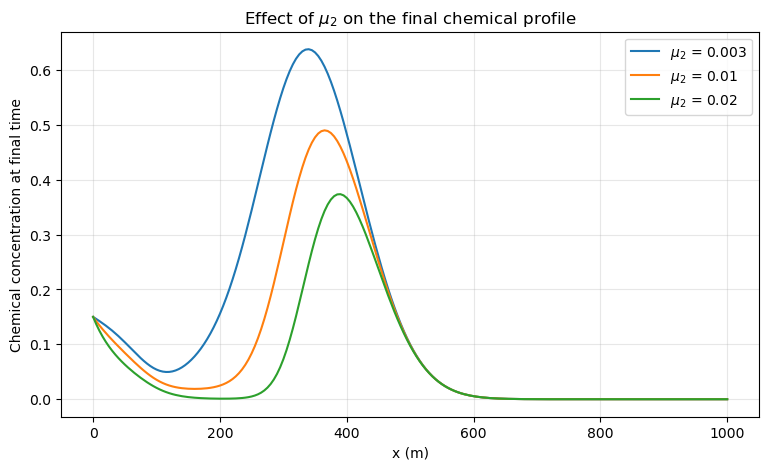

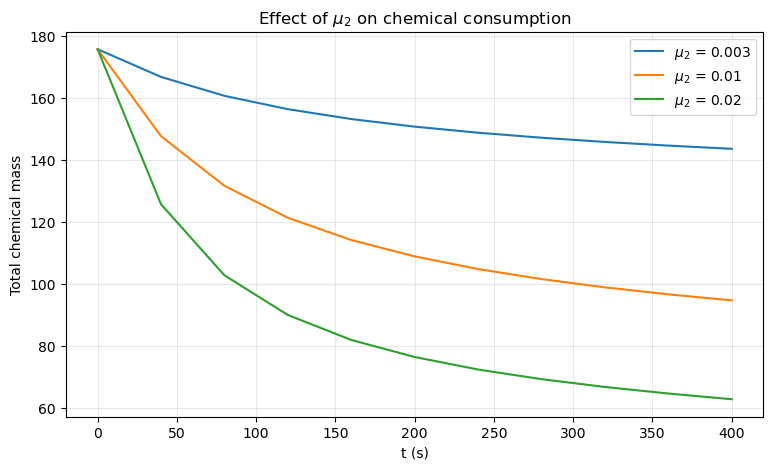

In [12]:

mu2_values = [0.003, 0.010, 0.020]
results_mu2 = {}
for val in mu2_values:
    par = params.copy()
    par['mu2'] = val
    xm, tm, Sm, Cm = simulate(par, save_every=20)
    results_mu2[val] = (xm, tm, Sm, Cm)

plt.figure(figsize=(9,5))
for val in mu2_values:
    xm, tm, Sm, Cm = results_mu2[val]
    plt.plot(xm, Cm[-1], label=fr'$\mu_2$ = {val}')
plt.xlabel('x (m)')
plt.ylabel('Chemical concentration at final time')
plt.title('Effect of $\mu_2$ on the final chemical profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))
for val in mu2_values:
    xm, tm, Sm, Cm = results_mu2[val]
    masses = [total_mass(U, xm) for U in Cm]
    plt.plot(tm, masses, label=fr'$\mu_2$ = {val}')
plt.xlabel('t (s)')
plt.ylabel('Total chemical mass')
plt.title('Effect of $\mu_2$ on chemical consumption')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Interpretation
- A larger $\mu_2$ leads to a stronger loss of chemical during contact with sediment.
- The chemical profile becomes smaller when $\mu_2$ increases.
- The total chemical mass decreases faster, which shows that $\mu_2$ is important for the persistence of the chemical in the river.



## 12. General conclusion

The numerical simulations highlight the main mechanisms of the model.

### Main observations
1. The initial profiles strongly influence the early stage of the dynamics.
2. Advection moves both concentrations downstream.
3. Diffusion spreads the profiles and smooths their peaks.
4. The interaction terms are strongest in the spatial region where sediment and chemical overlap.
5. The parameter $\mu_1$ mainly controls sediment survival.
6. The parameter $\mu_2$ mainly controls chemical consumption during contact.

### Final remark
These results are qualitative and illustrative. They are suitable for understanding the structure of the model and the role of the parameters.
For a quantitative environmental study, one would need measured field data and a proper parameter calibration procedure.


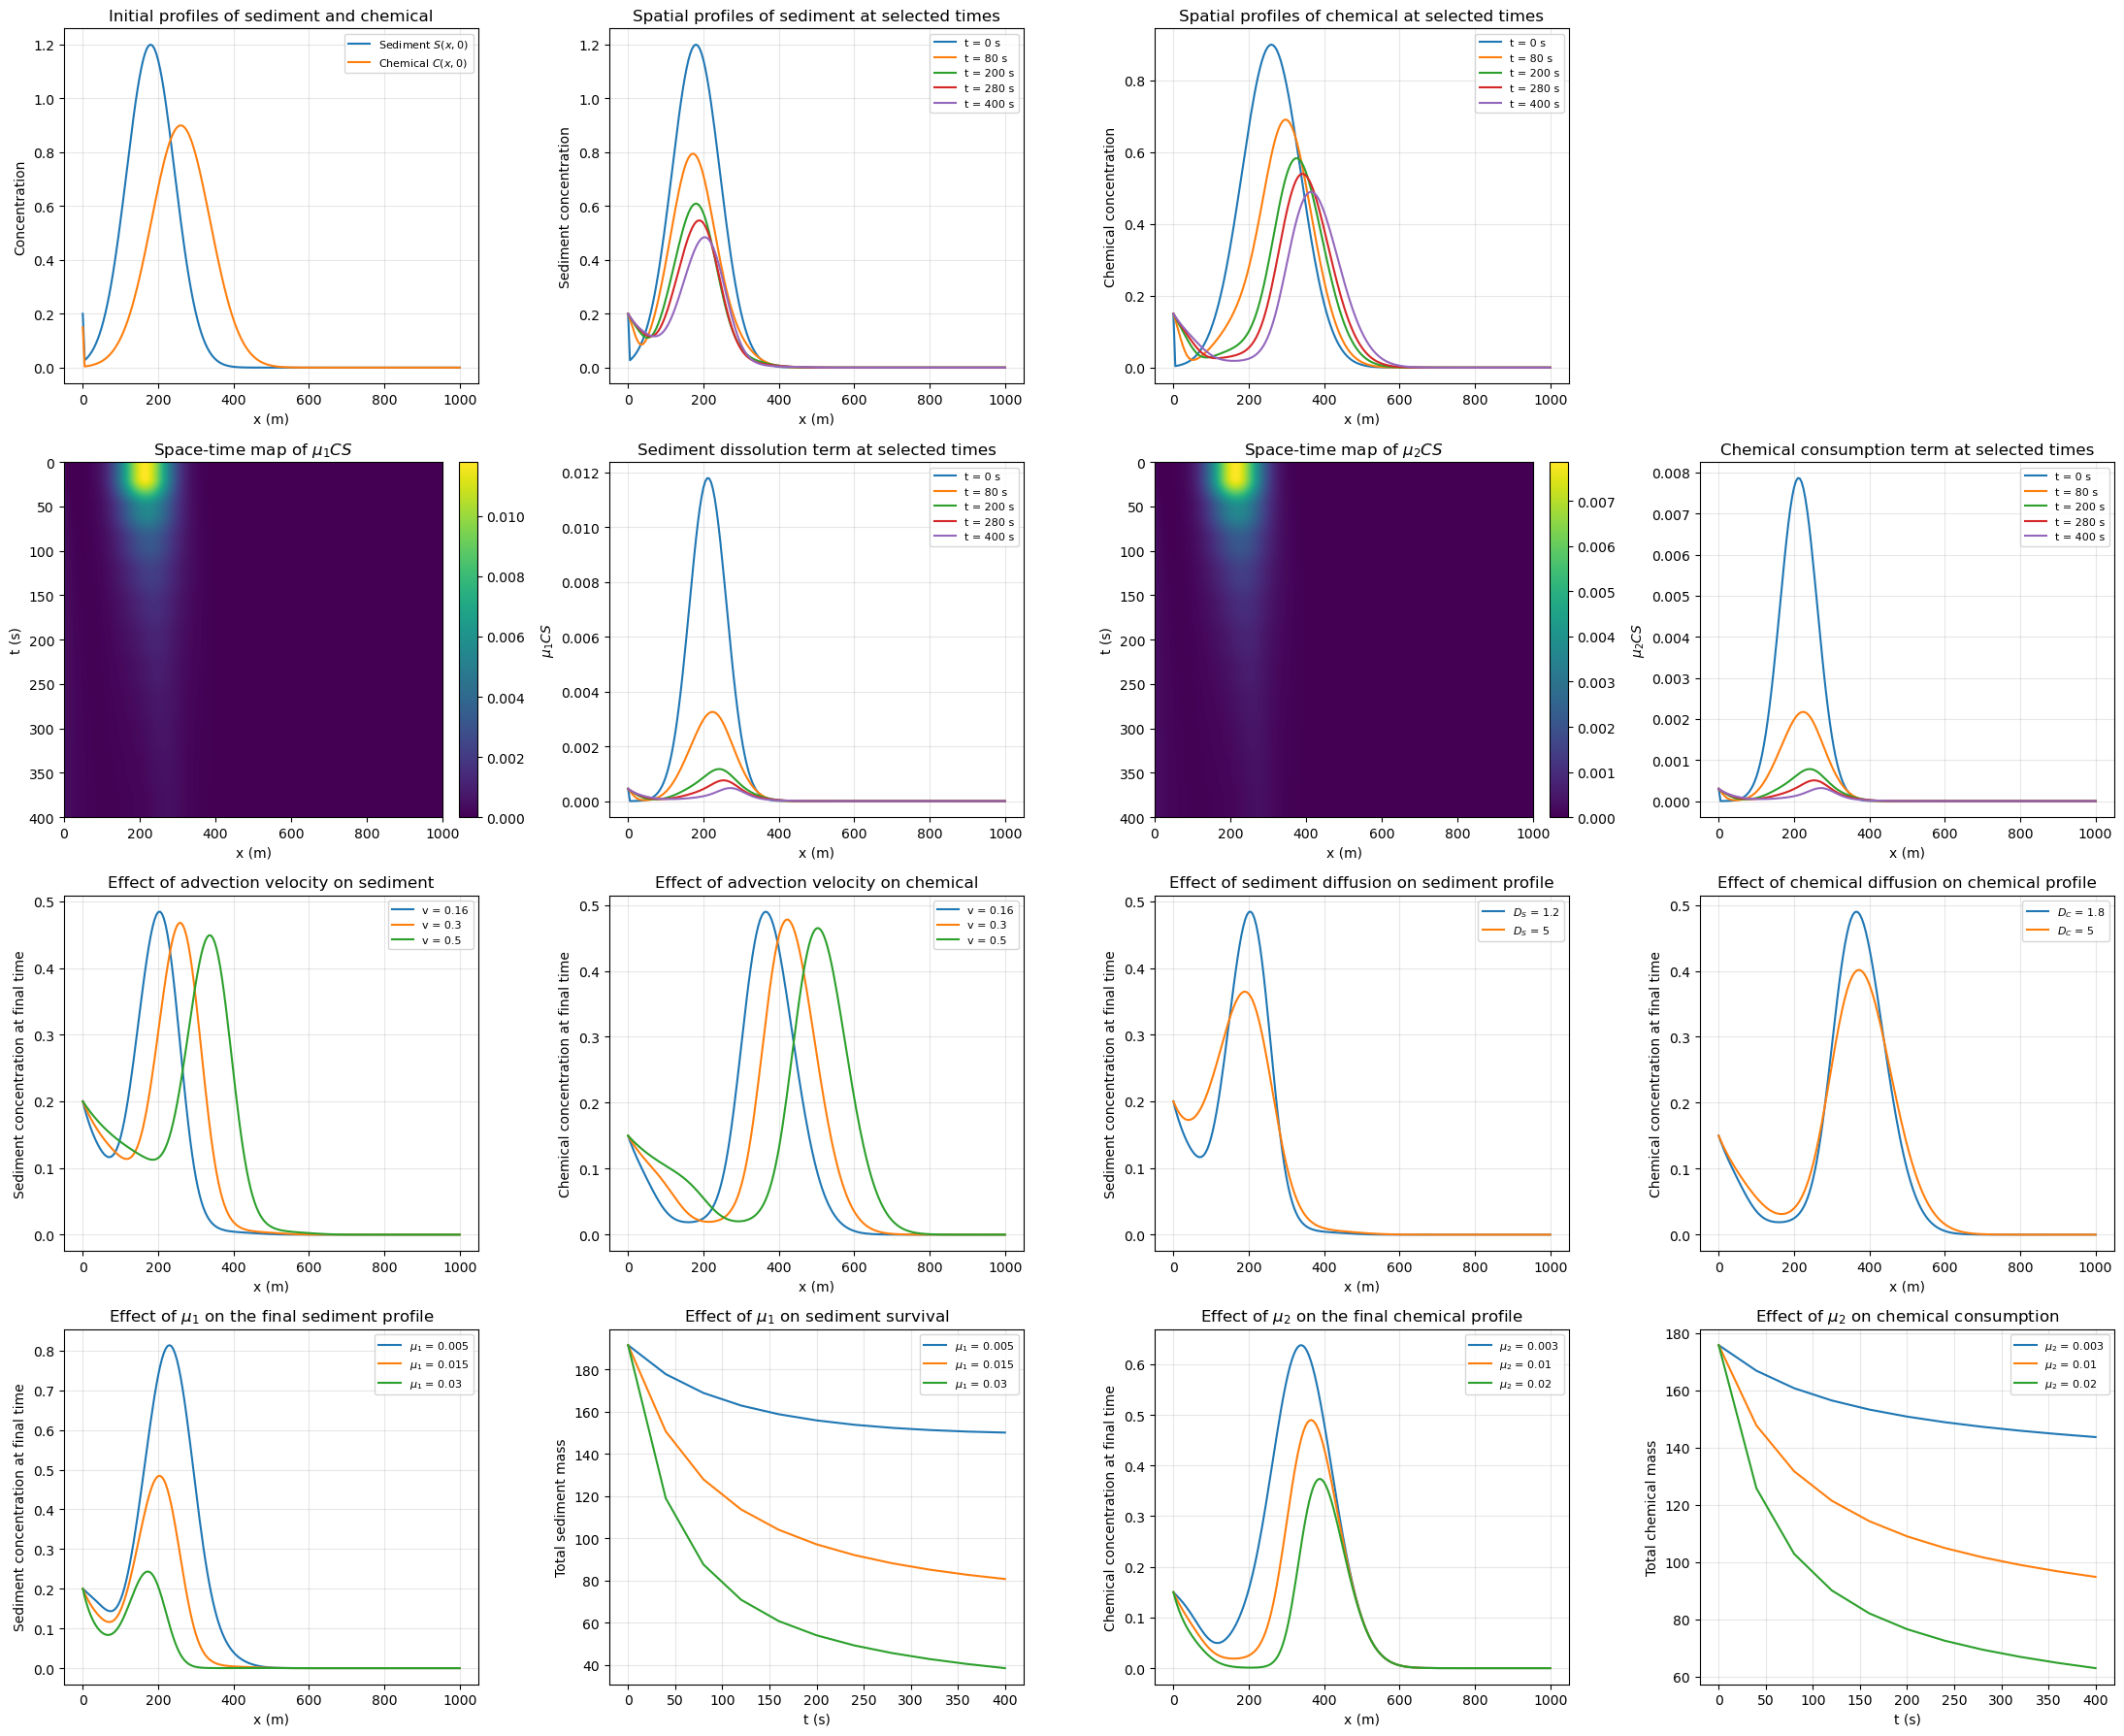

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Combined figure: 4 rows x 4 columns
# This cell assumes that the previous notebook cells were run.
# ------------------------------------------------------------

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.ravel()

# Common extent for space-time maps
extent = [x[0], x[-1], times[-1], times[0]]

# -------- 1st row: first 3 figures --------

# Figure 1: Initial profiles
ax = axes[0]
ax.plot(x, S_hist[0], label='Sediment $S(x,0)$')
ax.plot(x, C_hist[0], label='Chemical $C(x,0)$')
ax.set_title('Initial profiles of sediment and chemical')
ax.set_xlabel('x (m)')
ax.set_ylabel('Concentration')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 2: Spatial profiles of sediment
ax = axes[1]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, S_hist[idx], label=f't = {t:.0f} s')
ax.set_title('Spatial profiles of sediment at selected times')
ax.set_xlabel('x (m)')
ax.set_ylabel('Sediment concentration')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 3: Spatial profiles of chemical
ax = axes[2]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, C_hist[idx], label=f't = {t:.0f} s')
ax.set_title('Spatial profiles of chemical at selected times')
ax.set_xlabel('x (m)')
ax.set_ylabel('Chemical concentration')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Empty 4th panel in first row
axes[3].axis('off')

# -------- 2nd row: next 4 figures --------

# Figure 4: Space-time map of sediment dissolution term
ax = axes[4]
im1 = ax.imshow(R1, aspect='auto', extent=extent)
ax.set_title(r'Space-time map of $\mu_1 CS$')
ax.set_xlabel('x (m)')
ax.set_ylabel('t (s)')
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# Figure 5: Sediment dissolution term at selected times
ax = axes[5]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, R1[idx], label=f't = {t:.0f} s')
ax.set_title(r'Sediment dissolution term at selected times')
ax.set_xlabel('x (m)')
ax.set_ylabel(r'$\mu_1 CS$')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 6: Space-time map of chemical consumption term
ax = axes[6]
im2 = ax.imshow(R2, aspect='auto', extent=extent)
ax.set_title(r'Space-time map of $\mu_2 CS$')
ax.set_xlabel('x (m)')
ax.set_ylabel('t (s)')
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# Figure 7: Chemical consumption term at selected times
ax = axes[7]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, R2[idx], label=f't = {t:.0f} s')
ax.set_title(r'Chemical consumption term at selected times')
ax.set_xlabel('x (m)')
ax.set_ylabel(r'$\mu_2 CS$')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# -------- 3rd row: next 4 figures --------

# Figure 8: Effect of advection velocity on sediment
ax = axes[8]
for val in v_values:
    xv, tv, Sv, Cv = results_v[val]
    ax.plot(xv, Sv[-1], label=f'v = {val}')
ax.set_title('Effect of advection velocity on sediment')
ax.set_xlabel('x (m)')
ax.set_ylabel('Sediment concentration at final time')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 9: Effect of advection velocity on chemical
ax = axes[9]
for val in v_values:
    xv, tv, Sv, Cv = results_v[val]
    ax.plot(xv, Cv[-1], label=f'v = {val}')
ax.set_title('Effect of advection velocity on chemical')
ax.set_xlabel('x (m)')
ax.set_ylabel('Chemical concentration at final time')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 10: Effect of sediment diffusion on sediment profile
ax = axes[10]
for val in Ds_values:
    xd, td, Sd, Cd = results_Ds[val]
    ax.plot(xd, Sd[-1], label=fr'$D_S$ = {val}')
ax.set_title(r'Effect of sediment diffusion on sediment profile')
ax.set_xlabel('x (m)')
ax.set_ylabel('Sediment concentration at final time')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 11: Effect of chemical diffusion on chemical profile
ax = axes[11]
for val in Dc_values:
    xd, td, Sd, Cd = results_Dc[val]
    ax.plot(xd, Cd[-1], label=fr'$D_C$ = {val}')
ax.set_title(r'Effect of chemical diffusion on chemical profile')
ax.set_xlabel('x (m)')
ax.set_ylabel('Chemical concentration at final time')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# -------- 4th row: last 4 figures --------

# Figure 12: Effect of mu1 on final sediment profile
ax = axes[12]
for val in mu1_values:
    xm, tm, Sm, Cm = results_mu1[val]
    ax.plot(xm, Sm[-1], label=fr'$\mu_1$ = {val}')
ax.set_title(r'Effect of $\mu_1$ on the final sediment profile')
ax.set_xlabel('x (m)')
ax.set_ylabel('Sediment concentration at final time')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 13: Effect of mu1 on sediment survival
ax = axes[13]
for val in mu1_values:
    xm, tm, Sm, Cm = results_mu1[val]
    masses = [np.trapz(U, xm) for U in Sm]
    ax.plot(tm, masses, label=fr'$\mu_1$ = {val}')
ax.set_title(r'Effect of $\mu_1$ on sediment survival')
ax.set_xlabel('t (s)')
ax.set_ylabel('Total sediment mass')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 14: Effect of mu2 on final chemical profile
ax = axes[14]
for val in mu2_values:
    xm, tm, Sm, Cm = results_mu2[val]
    ax.plot(xm, Cm[-1], label=fr'$\mu_2$ = {val}')
ax.set_title(r'Effect of $\mu_2$ on the final chemical profile')
ax.set_xlabel('x (m)')
ax.set_ylabel('Chemical concentration at final time')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Figure 15: Effect of mu2 on chemical consumption
ax = axes[15]
for val in mu2_values:
    xm, tm, Sm, Cm = results_mu2[val]
    masses = [np.trapz(U, xm) for U in Cm]
    ax.plot(tm, masses, label=fr'$\mu_2$ = {val}')
ax.set_title(r'Effect of $\mu_2$ on chemical consumption')
ax.set_xlabel('t (s)')
ax.set_ylabel('Total chemical mass')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()

# Save the final file
#plt.savefig("save.png", dpi=300, bbox_inches="tight")
plt.show()

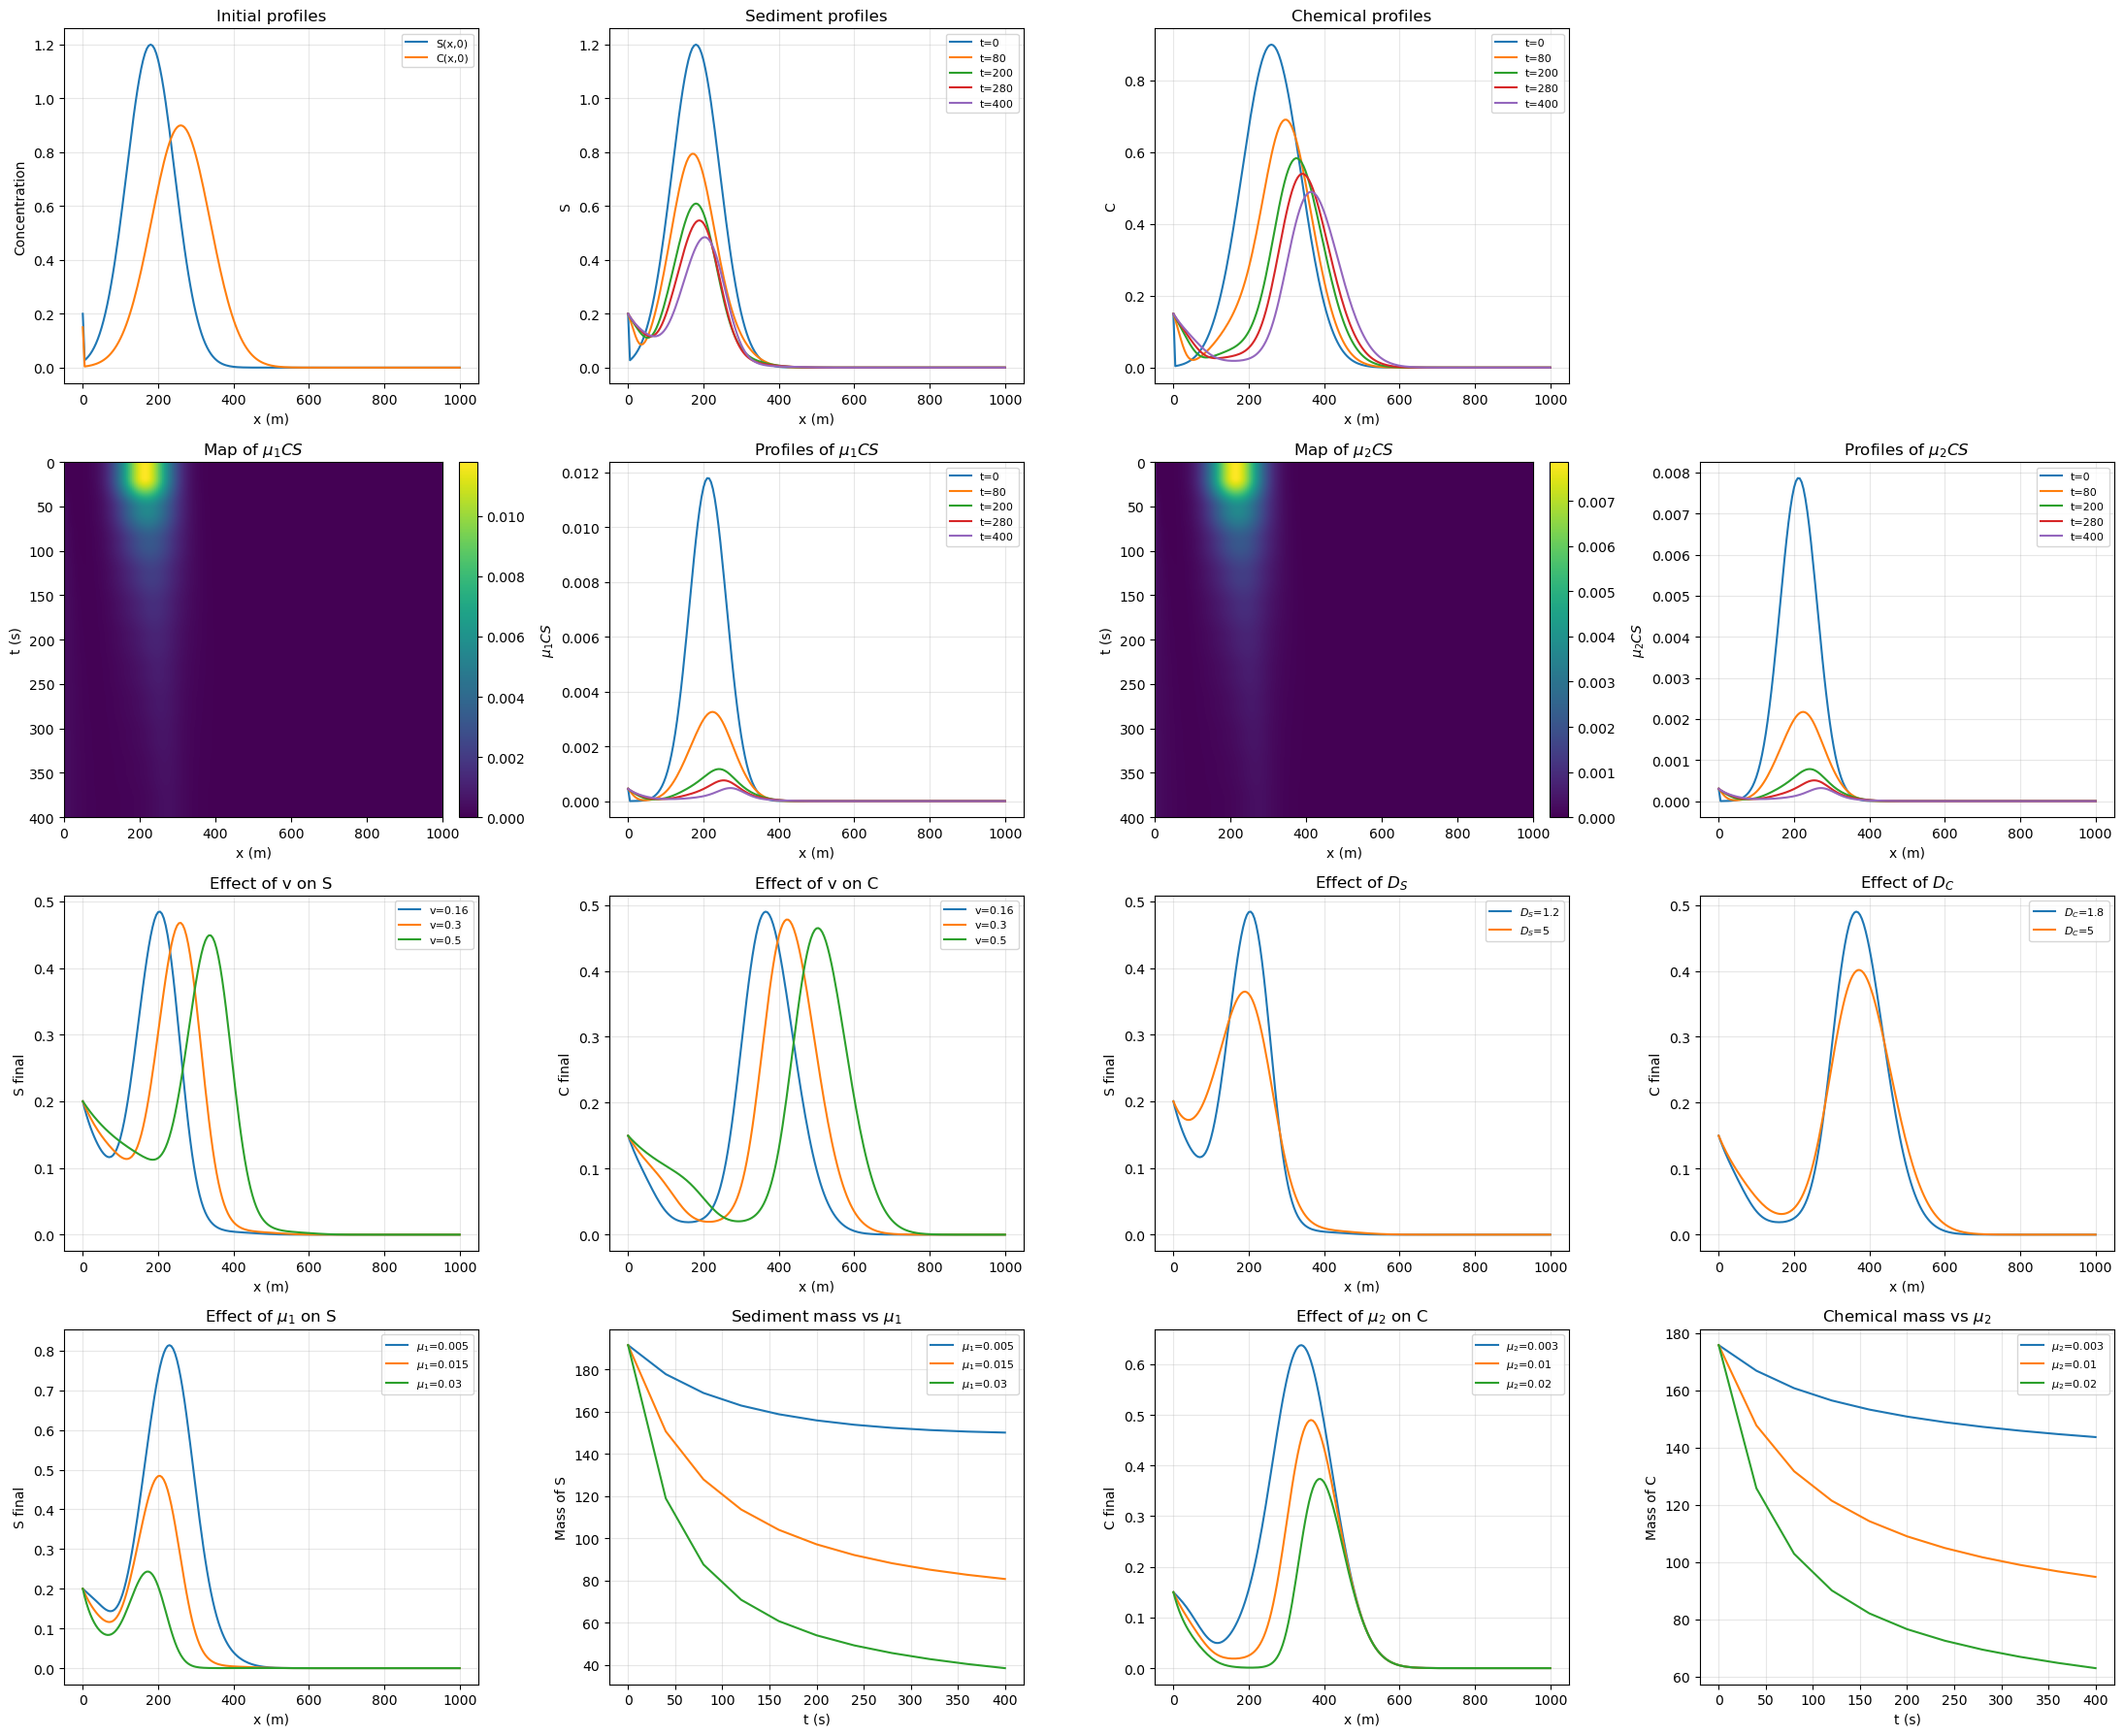

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Combined figure: 4 rows x 4 columns
# This cell assumes that the previous notebook cells were run.
# ------------------------------------------------------------

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.ravel()

extent = [x[0], x[-1], times[-1], times[0]]

# ---------------- 1st row ----------------

# 1
ax = axes[0]
ax.plot(x, S_hist[0], label='S(x,0)')
ax.plot(x, C_hist[0], label='C(x,0)')
ax.set_title('Initial profiles')
ax.set_xlabel('x (m)')
ax.set_ylabel('Concentration')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 2
ax = axes[1]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, S_hist[idx], label=f't={t:.0f}')
ax.set_title('Sediment profiles')
ax.set_xlabel('x (m)')
ax.set_ylabel('S')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 3
ax = axes[2]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, C_hist[idx], label=f't={t:.0f}')
ax.set_title('Chemical profiles')
ax.set_xlabel('x (m)')
ax.set_ylabel('C')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Empty panel
axes[3].axis('off')

# ---------------- 2nd row ----------------

# 4
ax = axes[4]
im1 = ax.imshow(R1, aspect='auto', extent=extent)
ax.set_title(r'Map of $\mu_1CS$')
ax.set_xlabel('x (m)')
ax.set_ylabel('t (s)')
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# 5
ax = axes[5]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, R1[idx], label=f't={t:.0f}')
ax.set_title(r'Profiles of $\mu_1CS$')
ax.set_xlabel('x (m)')
ax.set_ylabel(r'$\mu_1CS$')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 6
ax = axes[6]
im2 = ax.imshow(R2, aspect='auto', extent=extent)
ax.set_title(r'Map of $\mu_2CS$')
ax.set_xlabel('x (m)')
ax.set_ylabel('t (s)')
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# 7
ax = axes[7]
for idx, t in zip(selected_ids, selected_times_used):
    ax.plot(x, R2[idx], label=f't={t:.0f}')
ax.set_title(r'Profiles of $\mu_2CS$')
ax.set_xlabel('x (m)')
ax.set_ylabel(r'$\mu_2CS$')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# ---------------- 3rd row ----------------

# 8
ax = axes[8]
for val in v_values:
    xv, tv, Sv, Cv = results_v[val]
    ax.plot(xv, Sv[-1], label=f'v={val}')
ax.set_title('Effect of v on S')
ax.set_xlabel('x (m)')
ax.set_ylabel('S final')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 9
ax = axes[9]
for val in v_values:
    xv, tv, Sv, Cv = results_v[val]
    ax.plot(xv, Cv[-1], label=f'v={val}')
ax.set_title('Effect of v on C')
ax.set_xlabel('x (m)')
ax.set_ylabel('C final')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 10
ax = axes[10]
for val in Ds_values:
    xd, td, Sd, Cd = results_Ds[val]
    ax.plot(xd, Sd[-1], label=fr'$D_S$={val}')
ax.set_title(r'Effect of $D_S$')
ax.set_xlabel('x (m)')
ax.set_ylabel('S final')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 11
ax = axes[11]
for val in Dc_values:
    xd, td, Sd, Cd = results_Dc[val]
    ax.plot(xd, Cd[-1], label=fr'$D_C$={val}')
ax.set_title(r'Effect of $D_C$')
ax.set_xlabel('x (m)')
ax.set_ylabel('C final')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# ---------------- 4th row ----------------

# 12
ax = axes[12]
for val in mu1_values:
    xm, tm, Sm, Cm = results_mu1[val]
    ax.plot(xm, Sm[-1], label=fr'$\mu_1$={val}')
ax.set_title(r'Effect of $\mu_1$ on S')
ax.set_xlabel('x (m)')
ax.set_ylabel('S final')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 13
ax = axes[13]
for val in mu1_values:
    xm, tm, Sm, Cm = results_mu1[val]
    masses = [np.trapz(U, xm) for U in Sm]
    ax.plot(tm, masses, label=fr'$\mu_1$={val}')
ax.set_title(r'Sediment mass vs $\mu_1$')
ax.set_xlabel('t (s)')
ax.set_ylabel('Mass of S')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 14
ax = axes[14]
for val in mu2_values:
    xm, tm, Sm, Cm = results_mu2[val]
    ax.plot(xm, Cm[-1], label=fr'$\mu_2$={val}')
ax.set_title(r'Effect of $\mu_2$ on C')
ax.set_xlabel('x (m)')
ax.set_ylabel('C final')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 15
ax = axes[15]
for val in mu2_values:
    xm, tm, Sm, Cm = results_mu2[val]
    masses = [np.trapz(U, xm) for U in Cm]
    ax.plot(tm, masses, label=fr'$\mu_2$={val}')
ax.set_title(r'Chemical mass vs $\mu_2$')
ax.set_xlabel('t (s)')
ax.set_ylabel('Mass of C')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("save.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# 1. Parameters of the model
# ============================================================

params_anim = {
    'L': 1000.0,      # length of the river domain
    'T': 400.0, #400.0,       # final time of the animation
    'Nx': 201,        # number of spatial points
    'dt': 2.0,        # time step
    'v': 0.16,        # advection velocity
    'D_S': 1.2,       # sediment diffusion coefficient
    'D_C': 1.8,       # chemical diffusion coefficient
    'mu1': 0.015,     # sediment dissolution rate
    'mu2': 0.010,     # chemical consumption rate
    'mu_C': 2e-4,     # natural chemical decay rate
    'S_in': 0.20,     # inlet sediment concentration
    'C_in': 0.15      # inlet chemical concentration
}

# ============================================================
# 2. Initial conditions S(x,0) and C(x,0)
# ============================================================

def S0(x):
    return 1.20 * np.exp(-((x - 180.0) / 90.0)**2)

def C0(x):
    return 0.90 * np.exp(-((x - 260.0) / 110.0)**2)

# ============================================================
# 3. Numerical solver
# ============================================================

def simulate(par, save_every=2):
    """
    Solve the coupled advection-diffusion-reaction system:
    
        S_t + v S_x = D_S S_xx - mu1 C S
        C_t + v C_x = D_C C_xx - mu2 C S - mu_C C

    The solution is saved every 'save_every' time steps.
    """

    L = par['L']
    T = par['T']
    Nx = par['Nx']
    dt = par['dt']
    v = par['v']
    D_S = par['D_S']
    D_C = par['D_C']
    mu1 = par['mu1']
    mu2 = par['mu2']
    mu_C = par['mu_C']
    S_in = par['S_in']
    C_in = par['C_in']

    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    Nt = int(T / dt)

    S = S0(x).copy()
    C = C0(x).copy()

    # Boundary conditions at initial time
    S[0] = S_in
    C[0] = C_in
    S[-1] = S[-2]
    C[-1] = C[-2]

    times = [0.0]
    S_hist = [S.copy()]
    C_hist = [C.copy()]

    for n in range(1, Nt + 1):

        S_old = S.copy()
        C_old = C.copy()

        # Upwind scheme for advection
        adv_S = -v * (S_old[1:-1] - S_old[:-2]) / dx
        adv_C = -v * (C_old[1:-1] - C_old[:-2]) / dx

        # Centered scheme for diffusion
        diff_S = D_S * (S_old[2:] - 2*S_old[1:-1] + S_old[:-2]) / dx**2
        diff_C = D_C * (C_old[2:] - 2*C_old[1:-1] + C_old[:-2]) / dx**2

        # Reaction terms
        react_S = -mu1 * S_old[1:-1] * C_old[1:-1]
        react_C = -mu2 * S_old[1:-1] * C_old[1:-1] - mu_C * C_old[1:-1]

        # Time update
        S[1:-1] = S_old[1:-1] + dt * (adv_S + diff_S + react_S)
        C[1:-1] = C_old[1:-1] + dt * (adv_C + diff_C + react_C)

        # Positivity correction
        S[1:-1] = np.maximum(S[1:-1], 0.0)
        C[1:-1] = np.maximum(C[1:-1], 0.0)

        # Boundary conditions
        S[0] = S_in
        C[0] = C_in

        # Zero diffusive flux at x = L
        S[-1] = S[-2]
        C[-1] = C[-2]

        # Save snapshots
        if n % save_every == 0 or n == Nt:
            times.append(n * dt)
            S_hist.append(S.copy())
            C_hist.append(C.copy())

    return x, np.array(times), np.array(S_hist), np.array(C_hist)

# ============================================================
# 4. Run the simulation
# ============================================================

x, times, S_hist, C_hist = simulate(params_anim, save_every=2)

print("Number of saved frames:", len(times))
print("Final time:", times[-1], "s")

# ============================================================
# 5. Create the animation
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

line_S, = ax.plot([], [], linewidth=2.5, label=r"Sediment $S(x,t)$")
line_C, = ax.plot([], [], linewidth=2.5, linestyle="--", label=r"Chemical $C(x,t)$")

ax.set_xlim(x[0], x[-1])

ymax = 1.1 * max(np.max(S_hist), np.max(C_hist))
ax.set_ylim(0, ymax)

ax.set_xlabel("Position x along the river (m)")
ax.set_ylabel("Concentration")
ax.set_title("Sediment--Chemical Transport Dynamics")
ax.grid(True, alpha=0.3)
ax.legend()

time_text = ax.text(
    0.02, 0.93, "",
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

def init():
    line_S.set_data([], [])
    line_C.set_data([], [])
    time_text.set_text("")
    return line_S, line_C, time_text

def update(frame):
    line_S.set_data(x, S_hist[frame])
    line_C.set_data(x, C_hist[frame])
    time_text.set_text(f"t = {times[frame]:.1f} s")
    return line_S, line_C, time_text

animation = FuncAnimation(
    fig,
    update,
    frames=len(times),
    init_func=init,
    interval=100,
    blit=True
)

# ============================================================
# 6. Save the animation as a GIF file
# ============================================================

gif_name = "sediment_chemical_animation.gif"

animation.save(
    gif_name,
    writer=PillowWriter(fps=10),
    dpi=120
)

plt.close()

print(f"The animation has been saved as: {gif_name}")

Number of saved frames: 101
Final time: 400.0 s
The animation has been saved as: sediment_chemical_animation.gif


In [18]:
from PIL import Image
import os

gif_path = "sediment_chemical_animation.gif"
output_folder = "gif_frames"

os.makedirs(output_folder, exist_ok=True)

gif = Image.open(gif_path)

for frame_number in range(gif.n_frames):
    gif.seek(frame_number)
    frame = gif.convert("RGBA")
    frame.save(f"{output_folder}/frame_{frame_number:03d}.png")

print("Number of frames:", gif.n_frames)

Number of frames: 101


In [19]:
import shutil
from IPython.display import FileLink

# Nom du dossier à compresser
folder_name = "gif_frames"

# Créer un fichier ZIP
zip_file = shutil.make_archive(folder_name, 'zip', folder_name)

# Afficher un lien de téléchargement
FileLink(zip_file)

C:\Users\i7\Cours of PDEs\Final simulation\gif_frames.zip